[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/penny/gavd3/00_sjepa_from_first_principles.ipynb)

# 00. S-JEPA from first principles

Build a precise mental model of latent joint prediction and the normal-first curriculum before touching the GAVD videos.

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

**Run it:** locally, use `uv sync` then `uv run jupyter lab` from this folder. In Colab, use the badge and run the setup cell. Restart the kernel after changing `penny/gavd3/.env`.

**Keep the walk visible:** notebook 01 opens the source video, and notebook 02 shows frame, bbox, and skeleton alignment. Revisit those views whenever a latent or classifier result looks surprising.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd5-drift"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd5-drift" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: /Users/theodoremui/dev/alexpose
GAVD CSVs: /Users/theodoremui/dev/alexpose/data/gavd
YouTube cache: /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd5-drift/work/youtube
artifacts: /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real


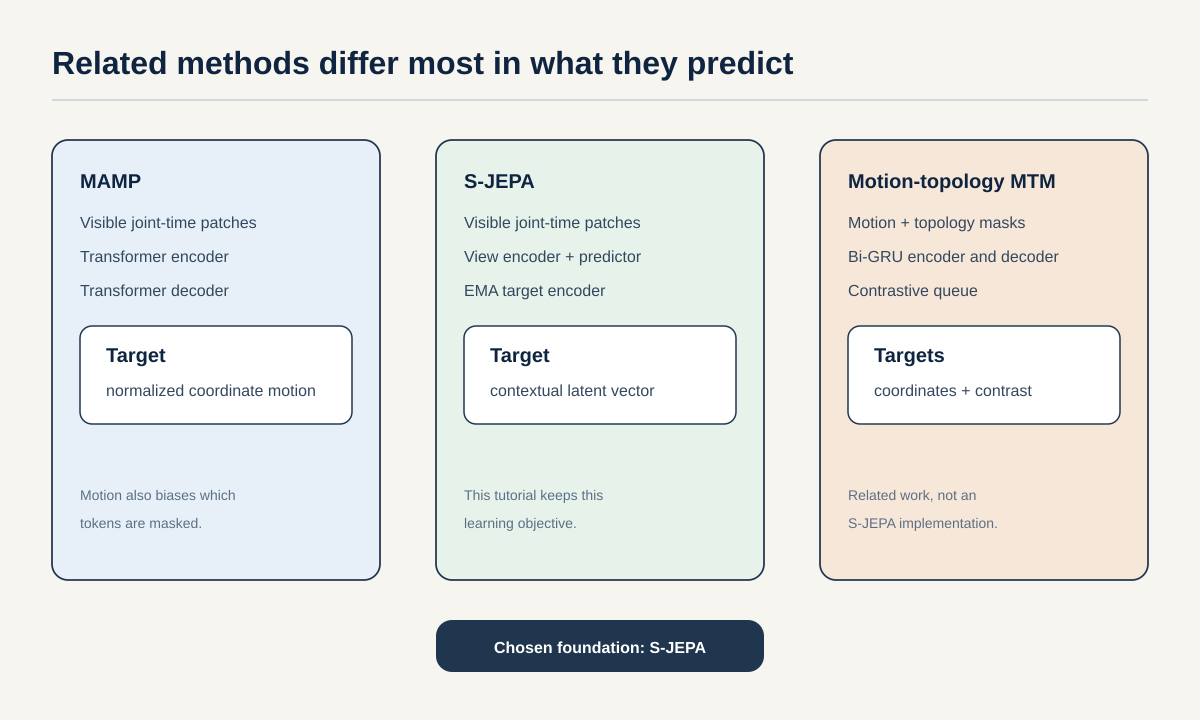

In [2]:
show_tutorial_svg("01_method_family.svg")


## The shortest useful definition

S-JEPA sees an incomplete set of joint-time patches and predicts the target encoder's contextual latent vectors for the missing patches. It does not reconstruct coordinates and it does not forecast future frames.

A joint-time patch contains one landmark across a short, non-overlapping temporal segment. With 64 frames, segment length 4, and 33 BlazePose joints:

\[
S = 64 / 4 = 16,\qquad N = 16 \times 33 = 528\text{ tokens}
\]


## Three methods that are easy to confuse

|Method|Mask input|Prediction target|Teacher branch|Training loss|
|---|---|---|---|---|
|MAMP, ICCV 2023|Visible joint-time patches|Segment-normalized temporal coordinate differences|None|Masked MSE|
|S-JEPA, ECCV 2024|Visible joint-time patches|Contextual target-encoder latent vectors|EMA target encoder|Soft-target cross-entropy|
|Motion-topology MTM, Scientific Reports 2026|Motion and topology body-part masks|Coordinate reconstruction plus contrastive representation|Momentum contrastive encoder|MSE plus InfoNCE and auxiliary loss|

The Nature paper is related work. It is not S-JEPA and its motion-topology sampler is prohibited in this experiment.


## MAMP predicts normalized motion, not a teacher latent

MAMP forms temporal coordinate differences from a skeleton sequence and normalizes them within temporal segments. In simplified notation:

$$
\Delta X_{t,j} = X_{t+1,j} - X_{t,j}, \qquad
\widehat{\Delta X} = \frac{\Delta X - \mu_{\mathrm{segment}}}{\sigma_{\mathrm{segment}} + \epsilon}
$$

Its encoder receives visible coordinate patches. A Transformer decoder reconstructs the normalized motion at masked positions, and masked MSE supplies the gradient. The original method uses motion magnitude to favor informative targets. It has no EMA teacher, target center, or latent soft-target distribution. This tutorial explains that mechanism but never imports its motion-aware sampler.

### MAMP training loop, step by step

1. Split the skeleton into temporal joint patches and embed their coordinates.
2. Compute frame-to-frame motion and normalize it inside each temporal segment. This normalized motion is the reconstruction target, not the encoder input.
3. Rank or sample mask locations using motion magnitude in the original method.
4. Remove the masked coordinate patches and encode the visible patches with a Transformer.
5. Insert learned mask tokens, add their space-time positions, and run a lightweight Transformer decoder.
6. Read decoder outputs only at masked positions and regress normalized motion with mean squared error.
7. Backpropagate through both encoder and decoder. There is no stop-gradient teacher.

```text
coordinates -> visible patches -> Transformer encoder
coordinates -> normalized temporal differences ------------+
encoded visible patches + mask tokens -> decoder -> masked MSE
```

MAMP's motion-aware selection is part of the source method, but it is intentionally replaced by uniform sampling over the fixed twelve-landmark set in this project.


## The 2026 MTM system is a separate hybrid design

The Scientific Reports system combines a three-layer bidirectional GRU encoder with a two-layer GRU reconstruction decoder. Its mask probability blends topology and motion cues. Training includes masked coordinate MSE, a momentum query-key contrastive path with a queue, multi-level augmentations, a temporal-gated feature-difference module, and auxiliary divergence losses.

Those components answer a different design question from S-JEPA's joint-token latent infilling. They are useful related ideas, but the blended motion-topology mask directly conflicts with this project's fixed twelve-landmark target rule.

### MTM training loop, step by step

1. Partition joints into body parts and combine topology importance with observed motion to choose masked coordinates.
2. Feed the masked sequence to the bidirectional GRU query encoder and reconstruct missing coordinates with the GRU decoder.
3. Build a second augmented view for a momentum-updated key encoder. The query and key paths form the positive contrastive pair.
4. Compare the query representation with its positive key and queued negative keys using InfoNCE.
5. Compute temporal-gated feature differences and the paper's auxiliary divergence terms.
6. Add reconstruction, contrastive, and auxiliary losses, then update the query-side networks by gradient descent.
7. Update the key encoder from the query encoder by momentum and refresh the negative queue.

```text
masked sequence -> BiGRU query -> GRU decoder -> coordinate MSE
        |                |
        |                +-> query representation -> InfoNCE
augmented view -> momentum key encoder -> positive key + queue
```

This hybrid learns a useful representation while reconstructing coordinates. S-JEPA instead asks a predictor to match contextual teacher latents and has no coordinate decoder or negative queue.


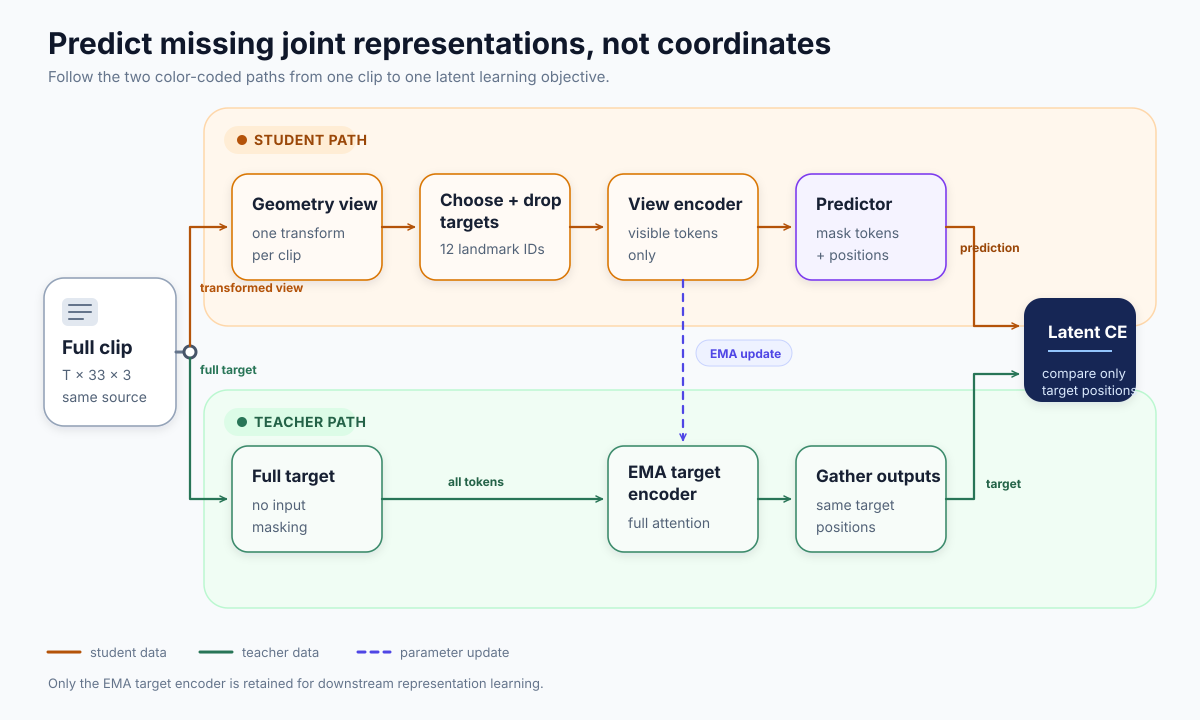

In [3]:
show_tutorial_svg("02_sjepa_architecture.svg")


## One paper-aligned core training step

1. Convert the full sequence into one token per temporal segment and joint.
2. Send every token to the target encoder. Select target positions only after the encoder has used full self-attention.
3. Apply one sequence-wide geometric transform to create the view.
4. Remove selected tokens before the trainable view encoder.
5. Restore learned mask tokens at the missing positions.
6. Send the complete layout through a Transformer predictor.
7. Compare predicted and target distributions at the selected positions.
8. Regularize two views with VICReg so the representation keeps useful variance and avoids redundant dimensions.
9. After the normal-only stage, add a bounded condition-centroid loss so known groups are compact and their normalized centroids stay separated.
10. Update the view encoder, predictor, and VICReg projector by gradient descent.
11. Update the target encoder with an exponential moving average of the view encoder.
12. Update the running target center.

The target encoder never receives a masked input. The S-JEPA target mask is sampled uniformly from the 12 authorized landmarks only. Neither the mask nor its probability uses displacement, velocity, acceleration, or any other motion score.


## The latent objective

Let \(R_p\) be predictor output, \(R_t\) be target-encoder output, \(c\) be the running target center, and \(\tau_p,\tau_t\) be temperatures.

\[
q = \operatorname{softmax}\left((R_t-c)/\tau_t\right)
\]

\[
\log p = \operatorname{logsoftmax}\left(R_p/\tau_p\right)
\]

\[
\mathcal{L} = -\frac{1}{M}\sum_{m=1}^{M} q_m^\top\log p_m
\]

The paper uses \(\tau_p=0.10\), \(\tau_t=0.06\), target-center momentum \(\beta=0.9\), and a target-encoder EMA that starts at 0.9999 and approaches 1.0. The tutorial scales EMA to its much smaller number of optimizer updates. Smoke and quick-validation profiles start at 0.996. The recommended real profile starts at 0.999 and runs longer. These are documented adaptations, not claimed paper hyperparameters.


## What this adaptation keeps and changes

|Component|ECCV S-JEPA|This GAVD tutorial|
|---|---|---|
|Token|One joint over 4 frames|Same|
|View encoder|Transformer over visible tokens|Same|
|Target encoder|Full input, EMA update|Same|
|Predictor|Transformer with mask tokens|Same|
|JEPA loss|Centered and sharpened latent cross-entropy|Same|
|Mask sampler|Motion-aware, 90 percent global mask|Uniform within 12 permitted BlazePose landmarks; motion is never scored|
|Anti-collapse|Teacher centering and sharpening|Teacher controls plus an explicit VICReg invariance/variance/covariance regularizer|
|Condition separation|Not part of the paper|A bounded, label-aware centroid compactness and margin term after Stage 0|
|Skeleton|Ground-truth 3D, 25 joints|Monocular BlazePose x, y, relative z, 33 joints|
|View augmentation|3D vertical-axis rotation and random temporal crop|Relative-coordinate vertical-axis rotation and translation; no random temporal crop|
|Downstream|Target encoder|Freeze only after the final curriculum stage, with documented pooling|

The mask list comes only from `experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md`. The valid-eligible ratio uses trackable positions among those 12 joints; the global ratio describes all 33 joints. The implementation never fills a quota with a forbidden joint.

### The required training order

|Stage|Data available to optimization|What continues from the prior stage|
|---:|---|---|
|0|`normal` only|Fresh view encoder and predictor|
|1|`normal + parkinsons`|Same model, EMA teacher, center, and VICReg projector|
|2|`normal + parkinsons + stroke`|Same state; balanced replay of earlier groups|
|3|`normal + parkinsons + stroke + myopathic`|Same state; balanced replay of earlier groups|
|4|`normal + parkinsons + stroke + myopathic + cerebralpalsy`|Same state; freeze only after this stage|

VICReg prevents collapse, but VICReg alone does **not** guarantee that condition groups move apart. That is why Stages 1–4 add a separate label-aware group term. Those stages are representation fine-tuning, not fully label-free self-supervised learning.


In [4]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


In [5]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


In [6]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    '''Fill only short internal gaps and preserve the original validity mask.

    Long gaps and sequence ends are never extrapolated. Their coordinates remain
    missing until center_and_scale converts them to an explicit zero sentinel.
    They can never become S-JEPA prediction targets.
    '''
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(
    sequence,
    frames=64,
    visibility_threshold=0.45,
    max_gap=4,
):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [7]:
def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, without motion scores.

    valid_patch has shape [B, S, V]. True means that a patch can be a target.
    The returned mask has the same shape. True means hidden from the view encoder.
    """
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for batch_index in range(len(mask)):
        candidates = np.flatnonzero(eligible[batch_index].reshape(-1))
        chosen = rng.choice(candidates, size=n_mask, replace=False)
        mask[batch_index].reshape(-1)[chosen] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    assert not mask[:, :, forbidden].any()
    assert mask.reshape(len(mask), -1).any(axis=1).all()
    assert (~mask).reshape(len(mask), -1).any(axis=1).all()
    return mask


def mask_audit(mask, valid_patch):
    mask = np.asarray(mask, dtype=bool)
    valid_patch = np.asarray(valid_patch, dtype=bool)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    masked_counts = mask.reshape(len(mask), -1).sum(axis=1)
    eligible_counts = eligible.reshape(len(mask), -1).sum(axis=1)
    per_sample_ratio = masked_counts / eligible_counts
    touched = np.flatnonzero(mask.any(axis=(0, 1))).tolist()
    return {
        "masked_keypoints": touched,
        "masked_names": [BLAZEPOSE_33[i] for i in touched],
        "global_fraction": float(mask.mean()),
        "eligible_mask_fraction_min": float(per_sample_ratio.min()),
        "eligible_mask_fraction_mean": float(per_sample_ratio.mean()),
        "eligible_mask_fraction_max": float(per_sample_ratio.max()),
        "forbidden_count": int(mask[:, :, sorted(set(range(33)) - set(MASK_KEYPOINTS))].sum()),
    }


In [8]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


def sjepa_cross_entropy(
    predicted,
    targets,
    center,
    predictor_temperature=0.10,
    target_temperature=0.06,
):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature,
        dim=-1,
    ).detach()
    prediction_log_prob = torch.log_softmax(
        predicted / predictor_temperature,
        dim=-1,
    )
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0


LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12),
    (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def geometric_view(
    x,
    max_degrees=8.0,
    translate=0.03,
    flip_probability=0.0,
):
    """Apply one sequence-wide transform per sample.

    Rotation is around the relative vertical y axis, so x and z are mixed.
    Flip defaults to off because laterality can matter for stroke. If enabled,
    coordinates are reflected and every left-right landmark pair is swapped.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (
        torch.rand(batch, device=x.device) * 2.0 - 1.0
    ) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x = view[..., 0].clone()
    original_z = view[..., 2].clone()
    rotated_x = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    rotated_z = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., 0] = rotated_x
    view[..., 2] = rotated_z
    offsets = (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    view[..., :2] += offsets
    if flip_probability > 0:
        flip = torch.rand(batch, device=x.device) < flip_probability
        for batch_index in torch.where(flip)[0].tolist():
            view[batch_index, ..., 0] *= -1.0
            original = view[batch_index].clone()
            original_present = present[batch_index].clone()
            for left, right in LEFT_RIGHT_PAIRS:
                view[batch_index, :, left] = original[:, right]
                view[batch_index, :, right] = original[:, left]
                present[batch_index, :, left] = original_present[:, right]
                present[batch_index, :, right] = original_present[:, left]
    view = view.masked_fill(~present[..., None], 0.0)
    return view


## Trace one synthetic batch

This is a shape and gradient smoke test, not an experiment result. It proves that the view encoder receives fewer tokens, the target encoder remains gradient-free, and the loss is finite.


In [9]:
toy = [
    synthetic_gait_sequence("normal", frames=32, seed=1),
    synthetic_gait_sequence("normal", frames=32, seed=2),
]
prepared = [prepare_sequence(item, frames=32) for item in toy]
xyz = np.stack([item[0] for item in prepared])
valid = np.stack([item[1] for item in prepared])
segment_length = 4
valid_patch = valid.reshape(
    len(valid), 8, segment_length, 33
).all(axis=2)
mask_np = uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=7)
print(mask_audit(mask_np, valid_patch))

batch = torch.tensor(xyz)
target_mask = torch.tensor(mask_np)
model = SJEPAGait(
    frames=32,
    segment_length=4,
    embed_dim=32,
    encoder_depth=1,
    predictor_depth=1,
    heads=4,
)
prediction, target = model(
    geometric_view(
        batch,
        flip_probability=0.0,
    ),
    batch,
    target_mask,
)
loss = sjepa_cross_entropy(
    prediction, target, model.target_center
)
loss.backward()

print("prediction shape:", tuple(prediction.shape))
print("target shape:", tuple(target.shape))
print("finite loss:", bool(torch.isfinite(loss)))
print(
    "target gradients:",
    sum(p.grad is not None for p in model.target_encoder.parameters()),
)
assert torch.isfinite(loss)
assert all(p.grad is None for p in model.target_encoder.parameters())


{'masked_keypoints': [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], 'masked_names': ['LEFT_SHOULDER', 'RIGHT_SHOULDER', 'LEFT_HIP', 'RIGHT_HIP', 'LEFT_KNEE', 'RIGHT_KNEE', 'LEFT_ANKLE', 'RIGHT_ANKLE', 'LEFT_HEEL', 'RIGHT_HEEL', 'LEFT_FOOT_INDEX', 'RIGHT_FOOT_INDEX'], 'global_fraction': 0.2159090909090909, 'eligible_mask_fraction_min': 0.59375, 'eligible_mask_fraction_mean': 0.59375, 'eligible_mask_fraction_max': 0.59375, 'forbidden_count': 0}
prediction shape: (2, 57, 32)
target shape: (2, 57, 32)
finite loss: True
target gradients: 0


/var/folders/b_/yqwhs_nd49x6qb8ypck81_n00000gn/T/ipykernel_81735/3075790523.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/b_/yqwhs_nd49x6qb8ypck81_n00000gn/T/ipykernel_81735/3075790523.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


## Do not call this future prediction

The missing target patches come from the same observed clip. The predictor learns contextual latent infilling. Generating future skeleton coordinates would require a different causal mask, a time horizon, and a coordinate decoder. Notebook 05 uses the word prediction only for the S-JEPA latent objective.

## Primary reading

- S-JEPA paper: https://www.ecva.net/papers/eccv_2024/papers_ECCV/papers/04755.pdf
- S-JEPA project page: https://sjepa.github.io/
- VICReg paper: https://arxiv.org/abs/2105.04906
- MAMP paper and official code (background only; its motion-aware sampler is never used here): https://openaccess.thecvf.com/content/ICCV2023/html/Mao_Masked_Motion_Predictors_are_Strong_3D_Action_Representation_Learners_ICCV_2023_paper.html and https://github.com/maoyunyao/MAMP
- Related motion-topology MTM paper: https://www.nature.com/articles/s41598-026-39330-9
